# Título
### Dogs v Cats


### 1.- Artículo y autores
El presente trabajo tiene como objetivo realizar un análisis sobre el capítulo 6 del libro "Advanced Deep Learning for Engineers and Scientists: A Practical Approach", titulado "Binary Classification Using Keras: Case Study". Este libro contiene diversos estudios, aplicaciones y metodologías orientadas a introducir y profundizar en técnicas de deep learning desde una perspectiva práctica.

#### Autores y editores
Los editores del libro son investigadores reconocidos en el ámbito de la inteligencia artificial, ingeniería informática y deep learning, donde su trayectoria combina trabajos académicos y publicaciones centradas en la aplicación práctica de modelos de IA.

#### Propósito del capítulo
El capítulo 6 tiene como objetivo presentar una guía práctica sobre un modelo de clasificación binaria utilizando Keras, una de las bibliotecas más utilizadas en Python. A través de un caso de estudio se muestra como preparar datos, construir un modelo, entrenarlo y evaluarlo.
Este apartado ofrece paso a paso el flujo completo de un proyecto real, desde el preprocesamiento hasta la interpretación de métricas como accuracy, loss, precision y recall, enfatizando también en la importancia de una adecuada selección de hiperparámetros para obtener resultados óptimos.

#### Relevancia
Esta parte del estudio es fundamental ya que es aplicable a múltiples áreas, por ejemplo:
- Detección de spam
- Clasificación de imágenes en categorías
- Diagnósticos médicos asistidos por IA

In [1]:
import keras
from keras import Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout, BatchNormalization, Conv2D, MaxPooling2D
import os

In [2]:
root_path = 'cats_and_dogs_filtered'

train_folder = os.path.join(root_path, 'train')
validation_folder = os.path.join(root_path, 'validation')

train_dogs_folder = os.path.join(train_folder, 'dogs')
train_cats_folder = os.path.join(train_folder, 'cats')

validation_dogs_folder = os.path.join(validation_folder, 'dogs')
validation_cats_folder = os.path.join(validation_folder, 'cats')

In [3]:
train_dog_filenames = os.listdir(train_dogs_folder)
train_cat_filenames = os.listdir(train_cats_folder)
validation_dog_filenames = os.listdir(validation_dogs_folder)
validation_cat_filenames = os.listdir(validation_cats_folder)

print('Train filenames:')
print(train_dog_filenames[:5])
print(train_cat_filenames[:5])

print('Validation filenames:')
print(validation_dog_filenames[:5])
print(validation_cat_filenames[:5])

Train filenames:
['dog.0.jpg', 'dog.1.jpg', 'dog.10.jpg', 'dog.100.jpg', 'dog.101.jpg']
['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.101.jpg']
Validation filenames:
['dog.2000.jpg', 'dog.2001.jpg', 'dog.2002.jpg', 'dog.2003.jpg', 'dog.2004.jpg']
['cat.2000.jpg', 'cat.2001.jpg', 'cat.2002.jpg', 'cat.2003.jpg', 'cat.2004.jpg']


In [4]:
dogs_num = len(train_dog_filenames)
cats_num = len(train_cat_filenames)

print('training dog:', dogs_num)
print('training cat:', cats_num)

val_dogs_num = len(validation_dog_filenames)
val_cats_num = len(validation_cat_filenames)

print('validation dog:', val_dogs_num)
print('validation cat:', val_cats_num)

training dog: 1000
training cat: 1000
validation dog: 500
validation cat: 500


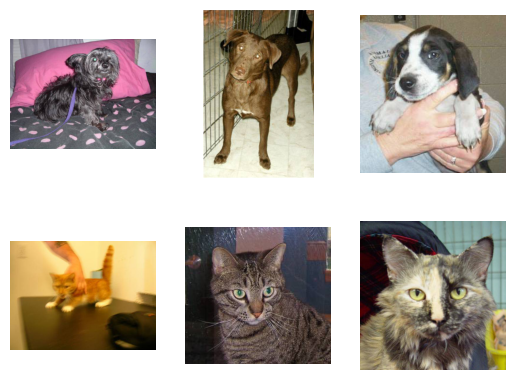

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dog_path = train_dogs_folder+'\\'
cat_path = train_cats_folder+'\\'

plt.subplot(231)
plt.imshow(mpimg.imread(dog_path+train_dog_filenames[0]))
plt.axis('Off')
plt.subplot(232)
plt.imshow(mpimg.imread(dog_path+train_dog_filenames[1]))
plt.axis('Off')
plt.subplot(233)
plt.imshow(mpimg.imread(dog_path+train_dog_filenames[2]))
plt.axis('Off')
plt.subplot(234)
plt.imshow(mpimg.imread(cat_path+train_cat_filenames[0]))
plt.axis('Off')
plt.subplot(235)
plt.imshow(mpimg.imread(cat_path+train_cat_filenames[1]))
plt.axis('Off')
plt.subplot(236)
plt.imshow(mpimg.imread(cat_path+train_cat_filenames[2]))
plt.axis('Off')
plt.savefig('Dog Cat.png', dpi=100)
plt.show()

In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(rescale = 1.0/255.,
                                        shear_range=0.2,
                                        zoom_range=0.2,
                                        horizontal_flip=True)
validation_datagen  = ImageDataGenerator(rescale = 1.0/255.)

In [8]:
train_generator = train_datagen.flow_from_directory(train_folder,
                                                    batch_size=100,
                                                    class_mode='binary',
                                                    target_size=(150, 150))

validation_generator = train_datagen.flow_from_directory(validation_folder,
                                                    batch_size=100,
                                                    class_mode='binary',
                                                    target_size=(150, 150))

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


### X.- Modelo de red neuronal aplicado a la clasificación binaria
La siguiente parte de código corresponde a la construcción y entrenamiento de un modelo de red neuronal convolucional (CNN). Este tipo de arquitectura es especialmente adecuada para modelos de clasificación de imágenes, ya que extrae patrones relevantes de las imágenes.

#### X.1.- Construcción del modelo

In [9]:
model = Sequential()

Se utiliza un modelo Sequential, que permite apilar capas de forma lineal, es el modelo más sencillo ya que las operaciones se ejecutan con un orden fijo.

Además del modelo Sequential, en Keras podemos encontrar otras formas de definir las arquitecturas de redes neuronales que tienen mayor flexibilidad para modelos más avanzados:
- Functional API: Para arquitecturas no lineales
- Modelos por Subclassing: El modelo se define mediante una clase. Es la forma más flexible de crear un modelo, pero la que más experiencia requiere en programación y diseño de redes neuronales.

#### X.2.- Primer bloque


In [10]:
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

c:\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Conv2D(32, (3, 3)) aplica 32 filtros de tamaño 3x3, cada uno extrae un aspecto visual diferente: bordes, texturas, curvas, esquinas, etcétera. Obteniendo como salida 32 mapas de características

La activación de ReLU transforma los valores negativos en 0, esto acelera el entrenamiento y mejora la capacidad de aprendizaje.

BatchNormalization() normaliza la activación de la capa anterior, es decir, estabiliza, acelera y mejora el rendimiento.

MaxPooling2D(pool_size=(2, 2)) reduce el tamaño espacial de la imagen a la mitad, conservando la información más relevante y disminuyendo la carga computacional.

Dropout(0.25) desactiva un 25% de las neuronas durante el entrenamiento, para evitar un sobreajuste


#### X.3.- Segundo bloque


In [11]:
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

Conv2D(64, (3, 3)) incrementa a 64 filtros, aprendiendo características más complejas de las imágenes.

Las demás líneas de código repiten el patrón anterior:
- Normalización: estabiliza el aprendizaje
- MaxPooling: reduce dimensión
- Dropout: previene sobreajuste

#### X.4.- Tercer bloque


In [12]:
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

En esta etapa se aprenden patrones de alto nivel:
- 128 filtros que detectan estructuras más abstractas, como ojos, hocicos, etcétera.

Se repite la estructura anterior

#### X.5.- Aplanamiento y clasificación densa


In [13]:
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation='sigmoid'))

Flatten() transforma el mapa de características 2D en un vector de 1D para tener el formato adecuado para conectarlo a las neuronas de la capa densa

En una capa densa, cada neurona esta conectada a las neuronas de la capa anterior, en Dense(512, activation='relu') tendremos 512 neuronas donde cada una recibirá la información de Flatten(). La función de la capa densa es clasificar la imagen, ya que toma todas las características detectadas por las convoluciones, aprende a combinarlas y toma decisiones (gato o perro)

BatchNormalization y Dropout se añaden posteriormente para mejorar la estabilidad y evitar el sobreajuste

Dense(1, activation='sigmoid') es la capa de salida, aqui será donde la red toma la decisión final. Tenemos solo 1 neurona ya que la decisión es binaria: 0=gato y 1=perro. Sigmoid sirve para convertir el valor final en un número entre 0 y 1, que representará la probabilidad de que sea un gato o un perro.



#### X.6.- Compilación del modelo


In [14]:
model.compile(loss='binary_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

- loss='binary_crossentropy': función de pérdida estándar para clasificación binaria, mide qué tan bien o mal esta aprendiendo el modelo. Esta es la más adecuada para clasificación binaria
- optimizer='rmsprop': optimizador eficiente para redes profundas.
- metrics=['accuracy']: métrica principal para evaluar rendimiento, nos dice qué tan bien clasifica la red en términos de aciertos totales.

#### X.7.- Entrenamiento


In [17]:
history = model.fit(train_generator, validation_data=validation_generator, epochs=200, verbose=2)

Epoch 1/200


KeyboardInterrupt: 

Ahora entrenamos el modelo usando las imágenes de entrenamiento.

Usa la validación para medir rendimiento en datos no vistos.

epochs=1000 son las pasadas completas que se realizan por todo el conjunto de datos de entrenamiento. Se ha establecido un número alto de 1000 epochs, lo cual puede generar sobreajuste, para evitarlo usaremos epochs=200.

verbose=2 mostrará una línea de información por cada epoch

In [ ]:
train_generator.class_indices

Muestra el diccionario donde Keras indica qué número asigna a cada cat y dog según las carpetas de entrenamiento. Esto permite interpretar correctamente las predicciones.

In [ ]:
from keras.preprocessing import image
import numpy as np

# load a new image
filename = 'cat.jpg'
img = image.load_img(filename, target_size=(150, 150))

# preprocess a new image
img = image.img_to_array(img)
img = np.expand_dims(img, axis=0)

# predict a new image
predicted_result = model.predict(img)
print(predicted_result[0][0])
if predicted_result[0][0] == 0:
    result = 'This image is a Cat.'
else:
    result = 'This image is a Dog.'
print(result)

### X.- Aplicaciones
El proyecto de clasificación binaria desarrollado en este trabajo no solo permite diferenciar imágenes entre gatos y perros. Constituye una base sólida para una amplia variedad de aplicaciones prácticas e interesantes, ya que el enfoque empleado puede extrapolarse a casos reales.
#### X.1 Visión artificial para la identificación de objetos
El mismo modelo puede adaptarse para distinguir cualquier par de clases:
- Tipos de vehículo (coche/moto)

Los sistemas de visión de los coches Tesla Autopilot usan modelos de redes convolucionales para diferenciar entre peatones, señales, semáforos, coches y más.
#### X.2 Detección temprana de enfermedades
La clasificación binaria es ampliamente utilizada en el ámbito médico para:
- Detectar tumores en imágenes de resonancia o radiografías
- Identificar signos tempranos de enfermedades oculares
- Distinguir entre tejidos sanos y anómalos

Modelos similares como el de Google DeepMind han demostrado una precisión comparable o superior a especialistas al detectar retinopatía diabética.
#### X.3 Seguridad y vigilancia inteligentes
Los modelos CNN permiten implementar sistemas de análisis visual que automaticen tareas como:
- Detección de personas desconocidas en espacios restringidos
- Identificación de comportamientos sospechosos
- Reconocimiento facial básico (autorizado/no autorizado)

Se demuestra la alta capacidad de estos modelos trabajando en tiempo real como el sistema de videovigilancia de Huawei Cloud EI, que identifican intrusos y comportamientos extraños en instalaciones.
#### X.4 Clasificación de contenido en redes sociales
La misma técnica puede usarse para:
- Filtrar contenido inapropiado
- Diferenciar imágenes reales de falsificaciones
- Organizar automáticamente álbumes o colecciones visuales

Cualquier red social como Instagram o Facebook usan modelos similares para detectar automáticamente contenido que viola las normas.
#### X.5 Industria y control de calidad
La clasificación por imágenes permite supervisar procesos industriales, por ejemplo:
- Distinguir productos defectuosos
- Detectar fallos en piezas
- Identificar anomalías en líneas de producción

Grandes fábricas como Bosch o Siemenes usan este tipo de modelos ayuda a reducir costes y aumentar la precisión del control de calidad.
#### X.6 Agricultura
- Identificar plagas en cultivos
- Diferenciar entre plantas sanas y enfermas
- Clasificar frutos según maduración o tamaño

La startup agrícola Plantix usa modelos de CNN para reconocer más de 50 enfermedades y plagas en plantas mediante fotos tomadas con el móvil.
#### X.7 Asistentes digitales y robótica
- Reconocer objetos del entorno
- Tomar decisiones basadas en imágenes
- Interactuar con el usuario y el entorno de forma más precisa

El nuevo robot doméstico Amazon Astro emplea modelos visuales basados en CNN para reconocer objetos y moverse de forma segura.

### X.- Referencias
[1] K. B. Prakash, R. Kannan, S. Albert Alexander, and G. R. Kanagachidambaresan, Advanced Deep Learning for Engineers and Scientists: A Practical Approach. Cham, Switzerland: Springer, 2021.

[2] I. Goodfellow, Y. Bengio, and A. Courville, Deep Learning. Cambridge, MA, USA: MIT Press, 2016.

[3] F. Chollet, Deep Learning with Python. Shelter Island, NY, USA: Manning Publications, 2018.

[4] K. O’Shea and R. Nash, “An introduction to convolutional neural networks,” arXiv preprint arXiv:1511.08458, 2015.

[5] V. Gulshan et al., “Development and validation of a deep learning algorithm for detection of diabetic retinopathy in retinal fundus photographs,” JAMA, vol. 316, no. 22, pp. 2402–2410, 2016.

[6] A. Esteva et al., “Dermatologist-level classification of skin cancer with deep neural networks,” Nature, vol. 542, pp. 115–118, 2017.

[7] A. Kamilaris and F. X. Prenafeta-Boldú, “Deep learning in agriculture: A survey,” Computers and Electronics in Agriculture, vol. 147, pp. 70–90, 2018.

[8] S. Qi, J. Yang, and Z. Zhong, “A review on industrial surface defect detection based on deep learning technology,” in Proc. 3rd Int. Conf. Machine Learning and Machine Intelligence (MLMI), 2020, pp. 24–30.

[9] J. Jiang et al., “Content moderation for social media: Current challenges and future directions,” ACM Computing Surveys, vol. 53, no. 1, pp. 1–33, 2020.